<a href="https://colab.research.google.com/github/sanahana2015-creator/AI-based-HeartAttack-prediction-system/blob/main/HeartAttack_model/HeartAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# problem statement

With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.


In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [249]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ) (9).csv')
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [250]:
df.tail()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [252]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [253]:
df.duplicated().sum()

np.int64(0)

In [254]:
df.shape

(237630, 35)

In [255]:
df.drop_duplicates(inplace=True)

In [256]:
df.shape

(237630, 35)

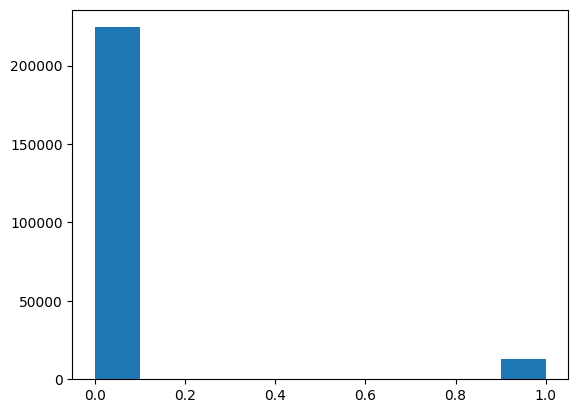

In [257]:
plt.hist(df['HadHeartAttack'])
plt.show()

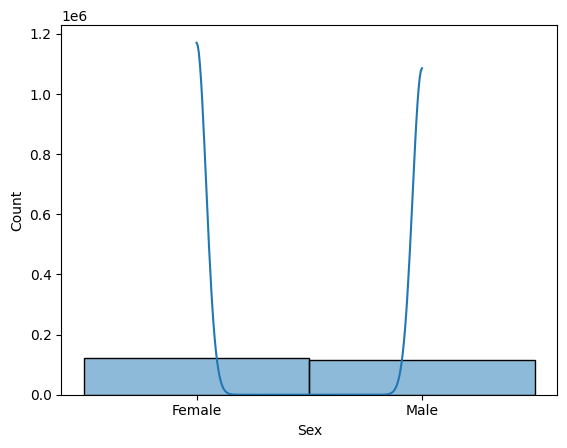

In [258]:
sns.histplot(df['Sex'], kde=True)
plt.show()

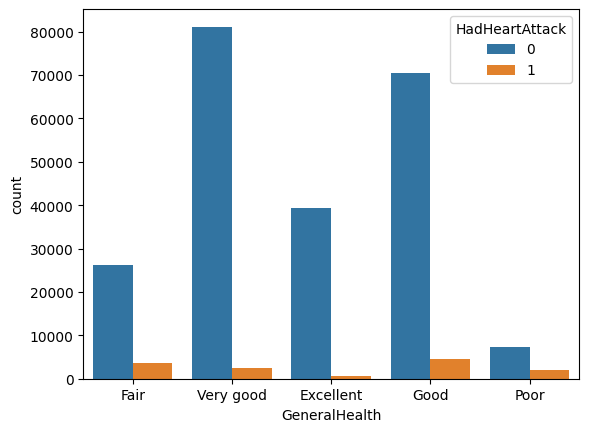

In [259]:
sns.countplot(data=df, x='GeneralHealth', hue='HadHeartAttack')
plt.show()

In [260]:
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [262]:
df['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'California', 'Arkansas',
       'Connecticut', 'Colorado', 'Delaware', 'Florida', 'Georgia',
       'Hawaii', 'Idaho', 'Indiana', 'District of Columbia', 'Kansas',
       'Iowa', 'Maryland', 'Minnesota', 'Montana', 'New Jersey',
       'Nebraska', 'New York', 'Ohio', 'Oklahoma', 'Texas', 'Vermont',
       'Washington', 'Utah', 'Illinois', 'West Virginia', 'Virginia',
       'Massachusetts', 'Kentucky', 'Louisiana', 'Maine', 'Wisconsin',
       'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire',
       'New Mexico', 'South Carolina', 'North Carolina', 'North Dakota',
       'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota',
       'Tennessee', 'Wyoming', 'Guam', 'Puerto Rico', 'Virgin Islands'],
      dtype=object)

In [263]:
df['Sex'].unique()

array(['Female', 'Male'], dtype=object)

In [264]:
df['GeneralHealth'].unique()

array(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'], dtype=object)

In [265]:
df['AgeCategory'].unique()

array(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'], dtype=object)

In [266]:
df['ECigaretteUsage'].unique()

array(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'], dtype=object)

In [267]:
df['RaceEthnicityCategory'].unique()

array(['White only, Non-Hispanic', 'Black only, Non-Hispanic',
       'Other race only, Non-Hispanic', 'Multiracial, Non-Hispanic',
       'Hispanic'], dtype=object)

In [268]:
df['TetanusLast10Tdap'].unique()

array(['No, did not receive any tetanus shot in the past 10 years',
       'Yes, received Tdap',
       'Yes, received tetanus shot but not sure what type',
       'Yes, received tetanus shot, but not Tdap'], dtype=object)

In [269]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])

In [270]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,4,0,0,0,1,0,0,1
1,2,0,0,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,4,0,0,1,1,1,0,0
2,3,0,1,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,4,1,0,0,0,2,0,0
3,4,0,1,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,4,0,0,1,1,2,0,0
4,5,0,0,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,1,0,0,1,0,0,0,0
237626,237627,40,0,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,1,0,1,0,0,1,0,0
237627,237628,40,1,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,1,0,1,1,1,1,1,0
237628,237629,40,0,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,1,0,1,0,0,0,0,1


In [271]:
df['GeneralHealth'].replace(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'],[0,1,2,3,4],inplace=True)

/tmp/ipykernel_633/2093440232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_633/2093440232.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace(['F

In [272]:
df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'],[77,67,62,72,52,85,57,27,42,32,37,21,47],inplace=True)

/tmp/ipykernel_633/3845665845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
/tmp/ipykernel_633/3845665845.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['AgeCategory'].replace(['Age 75 to 79', 'A

In [273]:
df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'],[0,1,2,3],inplace=True)

/tmp/ipykernel_633/1433195967.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life',
/tmp/ipykernel_633/1433195967.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ECigaretteUsage'].replace(['Never used e-cigarettes in m

In [274]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,0,77,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,1,67,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,2,62,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,1,72,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,3,52,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,3,62,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,3,57,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,0,47,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,1,27,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [275]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [276]:
df.dropna(inplace=True)

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [279]:
df['SmokerStatus']=pd.to_numeric(df['SmokerStatus'],errors='coerce')

In [280]:
df['HadDiabetes']=pd.to_numeric(df['SmokerStatus'],errors='coerce')

In [281]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,0,77,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,1,67,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,2,62,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,1,72,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,3,52,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,3,62,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,3,57,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,0,47,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,1,27,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [282]:
df['SmokerStatus'].fillna(df['SmokerStatus'].median(),inplace=True)

/tmp/ipykernel_633/4279406683.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SmokerStatus'].fillna(df['SmokerStatus'].median(),inplace=True)


In [283]:
df['HadDiabetes'].fillna(df['HadDiabetes'].median(),inplace=True)

/tmp/ipykernel_633/3631373075.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HadDiabetes'].fillna(df['HadDiabetes'].median(),inplace=True)


In [284]:
df.drop(["SmokerStatus"],axis=1,inplace=True)

In [285]:
df.drop(["HadDiabetes"],axis=1,inplace=True)

In [286]:
from imblearn.over_sampling import SMOTE
X=df.drop('HadHeartAttack',axis=1)
y = df['HadHeartAttack']
smote = SMOTE(random_state=42)
X_resampled,y_resampled = smote.fit_resample(X, y)
df=pd.concat([X_resampled,y_resampled],axis=1)


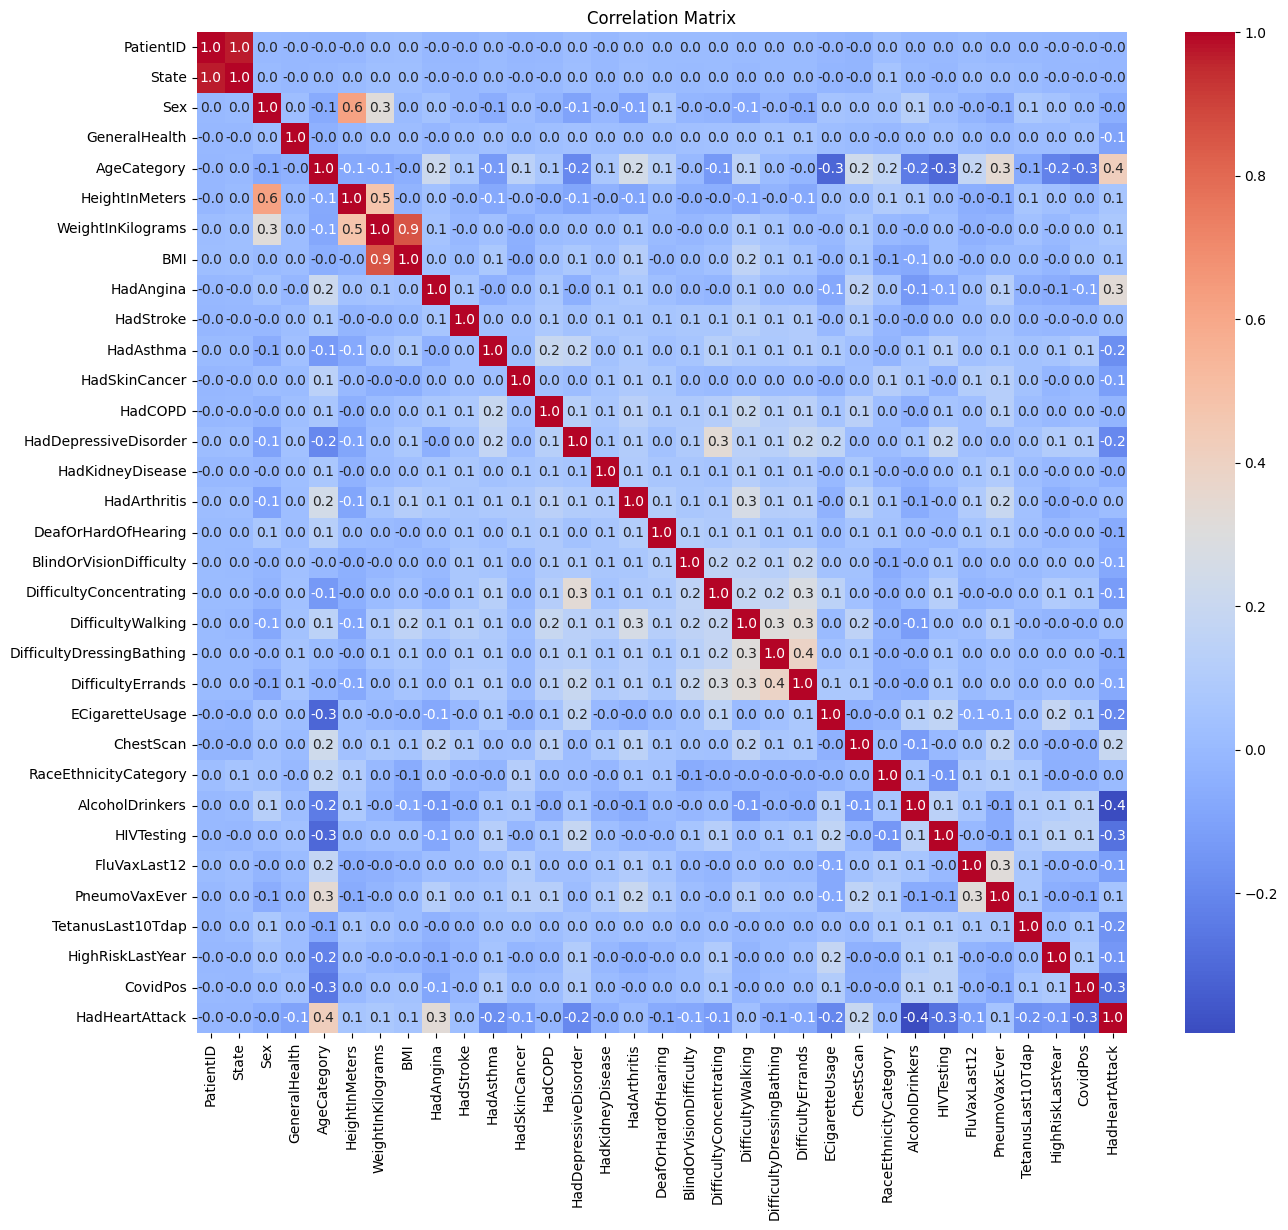

In [287]:
corr_matrix = df.corr()
plt.figure(figsize=(15,13))
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

In [288]:
df.drop(['PatientID','State','GeneralHealth','HIVTesting','TetanusLast10Tdap','HighRiskLastYear','CovidPos','Sex','HeightInMeters','WeightInKilograms','BMI','HadAsthma','HadSkinCancer','HadDepressiveDisorder','BlindOrVisionDifficulty','DifficultyConcentrating','DifficultyDressingBathing','DifficultyErrands','ECigaretteUsage','RaceEthnicityCategory','AlcoholDrinkers','FluVaxLast12'],axis=1,inplace=True)

<Axes: >

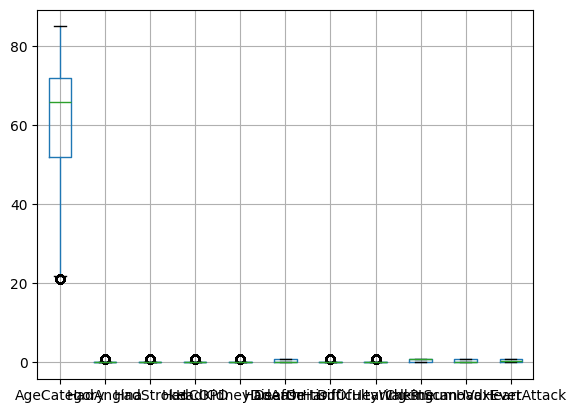

In [289]:
df.boxplot()

In [290]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:

        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df
df_cleaned=remove_outliers_iqr(df,exclude_column="price")
df=df_cleaned

In [291]:
df.shape

(275806, 11)

In [292]:
df

,AgeCategory,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,DeafOrHardOfHearing,DifficultyWalking,ChestScan,PneumoVaxEver,HadHeartAttack
1,67,0,0,0,0,1,0,0,0,1,0
2,62,0,0,0,0,0,0,0,0,0,0
3,72,0,0,0,0,1,0,0,0,1,0
4,52,0,0,0,0,0,0,0,1,0,0
6,72,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
448850,73,0,0,0,0,1,0,0,1,0,1
448851,57,0,0,0,0,0,0,0,1,0,1
448853,62,0,0,0,0,0,0,0,1,0,1
448855,66,0,0,0,0,0,0,0,1,0,1


In [293]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features=['AgeCategory','HadAngina','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','DifficultyWalking','ChestScan','PneumoVaxEver']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [294]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
X=df[['AgeCategory','HadAngina','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','DifficultyWalking','ChestScan','PneumoVaxEver']]
y=df["HadHeartAttack"]
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')


Baseline model accuracy: 0.71


# conclusion


This project developed a Logistic Regression model to predict whether a patient had experienced a heart attack (HadHeartAttack) using demographic, health, and lifestyle-related features. As a binary classification problem, the model learned patterns from the available data and achieved a baseline accuracy of 71%, indicating a reasonable ability to distinguish between patients with and without a history of heart attack.

The results demonstrate that patient health and lifestyle factors can be useful predictors of heart attack occurrence. While the model provides a solid baseline and offers interpretable predictions, future improvements could be achieved through feature engineering, hyperparameter tuning, and the use of more advanced machine learning algorithms to enhance predictive performance.